**Prerequisites**



In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn xgboost

**Part 1 : Data Preparation**

**Load and Explore Data**




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111004 entries, 0 to 111003
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    111004 non-null  int64  
 1   V1      111004 non-null  float64
 2   V2      111004 non-null  float64
 3   V3      111004 non-null  float64
 4   V4      111004 non-null  float64
 5   V5      111004 non-null  float64
 6   V6      111004 non-null  float64
 7   V7      111004 non-null  float64
 8   V8      111004 non-null  float64
 9   V9      111004 non-null  float64
 10  V10     111004 non-null  float64
 11  V11     111004 non-null  float64
 12  V12     111004 non-null  float64
 13  V13     111004 non-null  float64
 14  V14     111004 non-null  float64
 15  V15     111004 non-null  float64
 16  V16     111004 non-null  float64
 17  V17     111004 non-null  float64
 18  V18     111004 non-null  float64
 19  V19     111004 non-null  float64
 20  V20     111004 non-null  float64
 21  V21     11

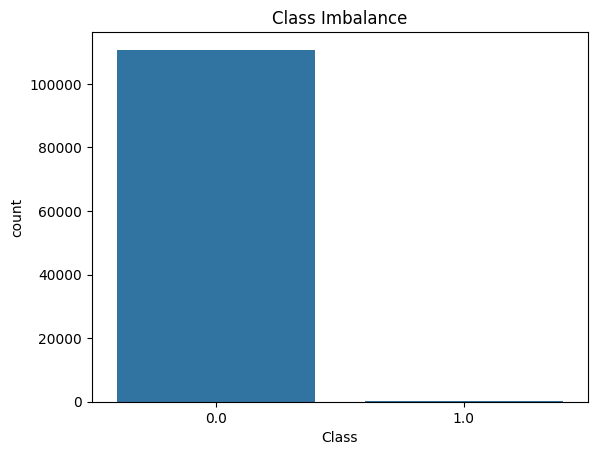

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('creditcard.csv')

print(df.info())  # Utility: 31 columns, no nulls (clean dataset)
print(df['Class'].value_counts(normalize=True))  # ~99.8% non-fraud
sns.countplot(x='Class', data=df)
plt.title('Class Imbalance')
plt.show()  # Visualizes skew

**Handle Outliers and Scale**

In [21]:
from sklearn.preprocessing import StandardScaler

time_scaler = StandardScaler()
amount_scaler = StandardScaler()

df['Time'] = time_scaler.fit_transform(df[['Time']])
df['Amount'] = amount_scaler.fit_transform(df[['Amount']])

# Outliers: Clip Amount (e.g., >3 std dev)
df['Amount'] = np.clip(df['Amount'], -3, 3)

**Split Data**

In [22]:
from sklearn.model_selection import train_test_split

# Drop rows with NaN values in the 'Class' column
df.dropna(subset=['Class'], inplace=True)

X = df.drop('Class', axis=1)  # Features
y = df['Class']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(y_train.value_counts(normalize=True))  # Utility: Confirm split balance

Class
0.0    0.997849
1.0    0.002151
Name: proportion, dtype: float64


**Part 2: Feature Engineering and Dimensionality Reduction**

**Apply PCA (Unsupervised)**

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # Keep 95% variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(X_train_pca.shape)  # Utility: e.g., reduces to ~20 components

(88802, 23)


**Handle Imbalance with SMOTE**

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)
print(y_train_smote.value_counts(normalize=True))  # Now ~50/50

Class
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


**Part 3: Build and Train Basic Models (Decision Tree & Random Forest)**

**Decision Tree**

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

tree = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
tree.fit(X_train_smote, y_train_smote)

preds_tree = tree.predict(X_test_pca)
print(classification_report(y_test, preds_tree))  # Utility: Focus on fraud recall/F1
print(f'ROC-AUC: {roc_auc_score(y_test, preds_tree):.4f}')  # Better for imbalance

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98     22153
         1.0       0.06      0.98      0.12        48

    accuracy                           0.97     22201
   macro avg       0.53      0.97      0.55     22201
weighted avg       1.00      0.97      0.98     22201

ROC-AUC: 0.9741


**Random Forest**

In [26]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
forest.fit(X_train_smote, y_train_smote)

preds_forest = forest.predict(X_test_pca)
print(classification_report(y_test, preds_forest))
print(f'ROC-AUC: {roc_auc_score(y_test, preds_forest):.4f}')

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     22153
         1.0       0.87      0.94      0.90        48

    accuracy                           1.00     22201
   macro avg       0.93      0.97      0.95     22201
weighted avg       1.00      1.00      1.00     22201

ROC-AUC: 0.9686


**Part 4: Advanced Techniques (Isolation Forest, Boosting, Tuning)**

**Isolation Forest (Unsupervised Anomaly Detection)**

In [27]:
from sklearn.ensemble import IsolationForest

# Train on non-fraud only using PCA-transformed data
iso = IsolationForest(contamination=0.0017, random_state=42)  # Fraud rate ~0.17%
iso.fit(X_train_pca[y_train == 0])

# Predict: -1 anomaly (fraud), 1 normal
anoms = iso.predict(X_test_pca)
preds_iso = np.where(anoms == -1, 1, 0)  # Map to 0/1

print(classification_report(y_test, preds_iso))
print(f'ROC-AUC: {roc_auc_score(y_test, preds_iso):.4f}')

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     22153
         1.0       0.32      0.35      0.34        48

    accuracy                           1.00     22201
   macro avg       0.66      0.68      0.67     22201
weighted avg       1.00      1.00      1.00     22201

ROC-AUC: 0.6763


**XGBoost (Advanced Boosting)**

In [28]:
import xgboost as xgb

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()  # Weight fraud higher
xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos, random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)

preds_xgb = xgb_model.predict(X_test_pca)
print(classification_report(y_test, preds_xgb))
print(f'ROC-AUC: {roc_auc_score(y_test, preds_xgb):.4f}')

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     22153
         1.0       0.55      0.94      0.69        48

    accuracy                           1.00     22201
   macro avg       0.77      0.97      0.85     22201
weighted avg       1.00      1.00      1.00     22201

ROC-AUC: 0.9679


**Hyperparameter Tuning with GridSearchCV**

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100], 'max_depth': [3, 5]}
grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train_smote, y_train_smote)

best_forest = grid.best_estimator_
print(f'Best Params: {grid.best_params_}, Best ROC-AUC: {grid.best_score_:.4f}')

Best Params: {'max_depth': 5, 'n_estimators': 100}, Best ROC-AUC: 0.9932


**Part 5: Ensemble and Evaluation**

**Voting Ensemble (Combines Models)**

In [30]:
 from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(estimators=[('tree', tree), ('forest', best_forest), ('xgb', xgb_model)], voting='soft')
ensemble.fit(X_train_smote, y_train_smote)

preds_ens = ensemble.predict(X_test_pca)
print(classification_report(y_test, preds_ens))
print(f'ROC-AUC: {roc_auc_score(y_test, preds_ens):.4f}')

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     22153
         1.0       0.47      0.96      0.63        48

    accuracy                           1.00     22201
   macro avg       0.74      0.98      0.82     22201
weighted avg       1.00      1.00      1.00     22201

ROC-AUC: 0.9780


**Precision-Recall Curve**

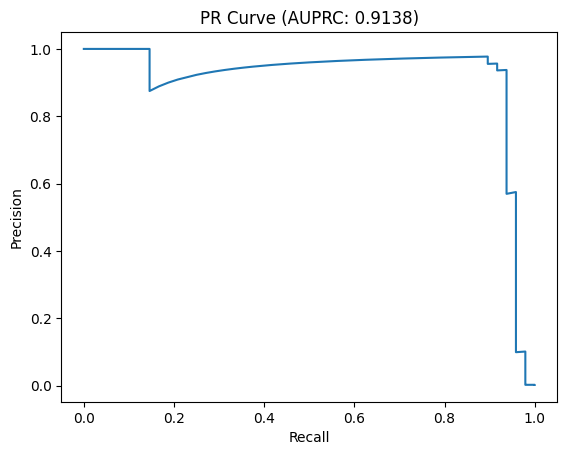

In [31]:
from sklearn.metrics import precision_recall_curve, auc

probs = ensemble.predict_proba(X_test_pca)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, probs)
auprc = auc(recall, precision)
plt.plot(recall, precision)
plt.title(f'PR Curve (AUPRC: {auprc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

**Deployment and Further Improvement**

**Deploy as App (Gradio)**

In [32]:
import gradio as gr
import numpy as np

# Assuming ensemble, pca, time_scaler, and amount_scaler are trained and available

def detect_fraud(time, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18, v19, v20, v21, v22, v23, v24, v25, v26, v27, v28, amount):
    inputs = np.array([[time, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18, v19, v20, v21, v22, v23, v24, v25, v26, v27, v28, amount]])

    # Scale Time and Amount using separate scalers
    inputs[0, 0] = time_scaler.transform([[inputs[0, 0]]])[0][0]
    inputs[0, -1] = amount_scaler.transform([[inputs[0, -1]]])[0][0]

    # Clip Amount for consistency
    inputs[0, -1] = np.clip(inputs[0, -1], -3, 3)

    # Apply PCA
    inputs_pca = pca.transform(inputs)

    # Predict
    prob = ensemble.predict_proba(inputs_pca)[0][1]
    prediction = "Fraud" if prob > 0.5 else "Legit"

    return prediction, f'Confidence: {prob * 100:.1f}%'

with gr.Blocks(title="Credit Card Fraud Detector") as demo:
    gr.Markdown("# Credit Card Fraud Detection App")
    gr.Markdown("Enter transaction details below. Use raw (unscaled) values for Time and Amount.")

    with gr.Row():
        with gr.Column():
            time_input = gr.Number(label="Time")
            amount_input = gr.Number(label="Amount")
        with gr.Column():
            v_inputs = [gr.Number(label=f"V{i}") for i in range(1, 29)]

    predict_btn = gr.Button("Detect Fraud")

    output_prediction = gr.Textbox(label="Prediction")
    output_confidence = gr.Textbox(label="Confidence")

    # Combine all inputs for the function
    all_inputs = [time_input] + v_inputs + [amount_input]

    predict_btn.click(fn=detect_fraud, inputs=all_inputs, outputs=[output_prediction, output_confidence])

    # Example input (from a sample non-fraud transaction; replace with actual if needed)
    gr.Examples(
        examples=[[
            0.0, -1.359807, -0.072781, 2.536347, 1.378155, -0.338321, 0.462388, 0.239599, 0.098698, 0.363787, 0.090794,
            -0.551600, -0.617801, -0.991390, -0.311169, 1.468177, -0.470401, 0.207971, 0.025791, 0.403993, 0.251412,
            -0.018307, 0.277838, -0.110474, 0.066928, 0.128539, -0.189115, 0.133558, -0.021053, 149.62
        ]],
        inputs=all_inputs
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bb201be7759615ca7e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
